# IFN680 Project 6 — The Sharpness Quest

This notebook implements the Project 6 experiment investigating whether adding a
discriminator-based loss to a Conditional Variational Autoencoder (cVAE) improves
the sharpness and quality of reconstructed/generated MNIST images.

The experiment will compare:

1. A baseline cVAE based on the Week 8 tutorial implementation.
2. The same cVAE extended with an additional discriminator/adversarial loss.

The baseline and modified models will use comparable training settings and a
7-dimensional latent space.

## 0. Environment and Project Setup
This section configures the Python/PyTorch environment, reproducibility settings,
GPU device, and project paths used throughout the experiment.



## 0.1 Project Imports
Import the PyTorch, numerical, visualisation, and utility packages required for
data preparation, cVAE training, evaluation, and result visualisation.

In [1]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid

from tqdm import tqdm

## 0.2 Reproducibility and Device

Set a fixed random seed to improve reproducibility and configure PyTorch to use
the available GPU where possible.

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.13.0+cu126
Using device: cuda:0
GPU: NVIDIA A16-4Q


## 0.3 Project Paths and data loading

Define the local paths used by the project and verify that the supplied
Project 6 dataset is available before beginning Task 1.

In [3]:
# Project dataset
DATA_PATH = Path("./mnist_custom-1.pt")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find dataset at: {DATA_PATH.resolve()}\n"
        "Upload mnist_custom.pt into the same directory as this notebook."
    )

print(f"Dataset found: {DATA_PATH.resolve()}")
print(f"File size: {DATA_PATH.stat().st_size / (1024 ** 2):.2f} MB")

Dataset found: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project6/mnist_custom-1.pt
File size: 107.35 MB


## 1. Task 1 — Train a Baseline cVAE

Task 1 establishes the control model for the Project 6 experiment.

The supplied modified MNIST dataset is used to train the standard conditional
Variational Autoencoder (cVAE) from Tutorial 8.3, adapted where required for the
project dataset. The model uses a **7-dimensional latent space** and is trained
until it converges and can produce reasonable conditional samples.

The resulting model provides the baseline against which the discriminator-loss
model developed in Task 2 will later be compared.

## 1.1 Dataset Inspection and Preparation

Load and inspect the supplied `mnist_custom` dataset before constructing the
training and test DataLoaders.

The inspection verifies the tensor shapes, value ranges, labels, and supplied
train/test split so that the Tutorial 8.3 data pipeline can be adapted to the
Project 6 dataset without making assumptions about its structure.

In [4]:
# Load the supplied Project 6 dataset onto CPU for inspection.
#
# weights_only=False is appropriate here because this is a trusted course-supplied
# PyTorch file rather than a model downloaded from an unknown source.

try:
    dataset_object = torch.load(
        DATA_PATH,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    # Compatibility with older PyTorch versions that do not expose weights_only.
    dataset_object = torch.load(
        DATA_PATH,
        map_location="cpu"
    )

print("Dataset loaded successfully.")
print(f"Top-level Python type: {type(dataset_object)}")

Dataset loaded successfully.
Top-level Python type: <class 'dict'>


In [5]:
def describe_object(obj, name="dataset", depth=0, max_depth=3):
    """
    Recursively inspect a loaded PyTorch object without assuming its structure.
    """
    indent = "    " * depth

    print(f"{indent}{name}: {type(obj).__name__}")

    if isinstance(obj, torch.Tensor):
        print(f"{indent}  shape: {tuple(obj.shape)}")
        print(f"{indent}  dtype: {obj.dtype}")
        print(f"{indent}  min: {obj.min().item() if obj.numel() else 'N/A'}")
        print(f"{indent}  max: {obj.max().item() if obj.numel() else 'N/A'}")
        return

    if depth >= max_depth:
        return

    if isinstance(obj, dict):
        print(f"{indent}  keys: {list(obj.keys())}")

        for key, value in obj.items():
            describe_object(
                value,
                name=f"[{repr(key)}]",
                depth=depth + 1,
                max_depth=max_depth
            )

    elif isinstance(obj, (list, tuple)):
        print(f"{indent}  length: {len(obj)}")

        for index, value in enumerate(obj):
            describe_object(
                value,
                name=f"[{index}]",
                depth=depth + 1,
                max_depth=max_depth
            )

    elif isinstance(obj, TensorDataset):
        print(f"{indent}  number of samples: {len(obj)}")
        print(f"{indent}  number of tensors: {len(obj.tensors)}")

        for index, tensor in enumerate(obj.tensors):
            describe_object(
                tensor,
                name=f"tensor[{index}]",
                depth=depth + 1,
                max_depth=max_depth
            )

    else:
        # Some dataset-like objects expose useful attributes.
        try:
            print(f"{indent}  length: {len(obj)}")
        except TypeError:
            pass


describe_object(dataset_object)

dataset: dict
  keys: ['train_images', 'train_labels', 'test_images', 'test_labels']
    ['train_images']: Tensor
      shape: (60000, 1, 20, 20)
      dtype: torch.float32
      min: 0.0
      max: 1.0
    ['train_labels']: Tensor
      shape: (60000,)
      dtype: torch.int64
      min: 0
      max: 9
    ['test_images']: Tensor
      shape: (10000, 1, 20, 20)
      dtype: torch.float32
      min: 0.0
      max: 1.0
    ['test_labels']: Tensor
      shape: (10000,)
      dtype: torch.int64
      min: 0
      max: 9


In [6]:
print("=== Top-level summary ===")

if isinstance(dataset_object, dict):
    for key, value in dataset_object.items():
        if isinstance(value, torch.Tensor):
            print(
                f"{key:20s} "
                f"shape={tuple(value.shape)}, "
                f"dtype={value.dtype}"
            )
        else:
            try:
                print(
                    f"{key:20s} "
                    f"type={type(value).__name__}, "
                    f"length={len(value)}"
                )
            except TypeError:
                print(
                    f"{key:20s} "
                    f"type={type(value).__name__}"
                )

elif isinstance(dataset_object, (tuple, list)):
    for i, value in enumerate(dataset_object):
        if isinstance(value, torch.Tensor):
            print(
                f"[{i}] "
                f"shape={tuple(value.shape)}, "
                f"dtype={value.dtype}"
            )
        else:
            try:
                print(
                    f"[{i}] "
                    f"type={type(value).__name__}, "
                    f"length={len(value)}"
                )
            except TypeError:
                print(
                    f"[{i}] "
                    f"type={type(value).__name__}"
                )

else:
    print(dataset_object)

=== Top-level summary ===
train_images         shape=(60000, 1, 20, 20), dtype=torch.float32
train_labels         shape=(60000,), dtype=torch.int64
test_images          shape=(10000, 1, 20, 20), dtype=torch.float32
test_labels          shape=(10000,), dtype=torch.int64


#### 1.1.4 Perapre Dataset Tensors

In [12]:
# 1.1.4 — Prepare Dataset Tensors

train_images = dataset_object["train_images"]
train_labels = dataset_object["train_labels"]

test_images = dataset_object["test_images"]
test_labels = dataset_object["test_labels"]

# Basic validation
assert train_images.ndim == 4
assert test_images.ndim == 4

assert train_images.shape[0] == train_labels.shape[0]
assert test_images.shape[0] == test_labels.shape[0]

assert train_images.shape[1:] == (1, 20, 20)
assert test_images.shape[1:] == (1, 20, 20)

assert train_images.dtype == torch.float32
assert test_images.dtype == torch.float32

assert train_labels.dtype == torch.int64
assert test_labels.dtype == torch.int64

print("Dataset tensors prepared successfully.")
print(f"Training samples: {len(train_images):,}")
print(f"Test samples:     {len(test_images):,}")
print(f"Image shape:      {tuple(train_images.shape[1:])}")
print(f"Pixel range:      [{train_images.min():.1f}, {train_images.max():.1f}]")
print(f"Classes:          {sorted(train_labels.unique().tolist())}")

Dataset tensors prepared successfully.
Training samples: 60,000
Test samples:     10,000
Image shape:      (1, 20, 20)
Pixel range:      [0.0, 1.0]
Classes:          [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### 1.1.5 Create Dataset Objects

In [14]:
# 1.1.5 — Create PyTorch Dataset Objects

train_dataset = TensorDataset(
    train_images,
    train_labels
)

test_dataset = TensorDataset(
    test_images,
    test_labels
)

print(f"Training dataset size: {len(train_dataset):,}")
print(f"Test dataset size:     {len(test_dataset):,}")

Training dataset size: 60,000
Test dataset size:     10,000


### 1.1.6 Create Data loaders

In [15]:
# 1.1.6 — Create Training and Test DataLoaders

BS_TRAIN = 1000
BS_TEST = 1000

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BS_TRAIN,
    shuffle=True,
    num_workers=0
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BS_TEST,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(train_dataloader)}")
print(f"Test batches:     {len(test_dataloader)}")
print(f"Training batch size: {BS_TRAIN}")
print(f"Test batch size:     {BS_TEST}")

Training batches: 60
Test batches:     10
Training batch size: 1000
Test batch size:     1000


### 1.1.7 Verify a dataloader Batch

In [16]:
# 1.1.7 — Verify DataLoader Batch Structure

sample_images, sample_labels = next(iter(train_dataloader))

print(f"Image batch shape: {tuple(sample_images.shape)}")
print(f"Label batch shape: {tuple(sample_labels.shape)}")
print(f"Image dtype:       {sample_images.dtype}")
print(f"Label dtype:       {sample_labels.dtype}")
print(f"Image value range: [{sample_images.min():.1f}, {sample_images.max():.1f}]")

Image batch shape: (1000, 1, 20, 20)
Label batch shape: (1000,)
Image dtype:       torch.float32
Label dtype:       torch.int64
Image value range: [0.0, 1.0]


### 1.1.8 Check Class Distribution

In [17]:
# 1.1.8 — Check Class Distribution

train_class_counts = torch.bincount(train_labels, minlength=10)
test_class_counts = torch.bincount(test_labels, minlength=10)

print("Class | Train | Test")
print("--------------------")

for digit in range(10):
    print(
        f"{digit:>5} | "
        f"{train_class_counts[digit].item():>5} | "
        f"{test_class_counts[digit].item():>4}"
    )

Class | Train | Test
--------------------
    0 |  5923 |  980
    1 |  6742 | 1135
    2 |  5958 | 1032
    3 |  6131 | 1010
    4 |  5842 |  982
    5 |  5421 |  892
    6 |  5918 |  958
    7 |  6265 | 1028
    8 |  5851 |  974
    9 |  5949 | 1009


### 1.1.9 Visualise Dataset Samples

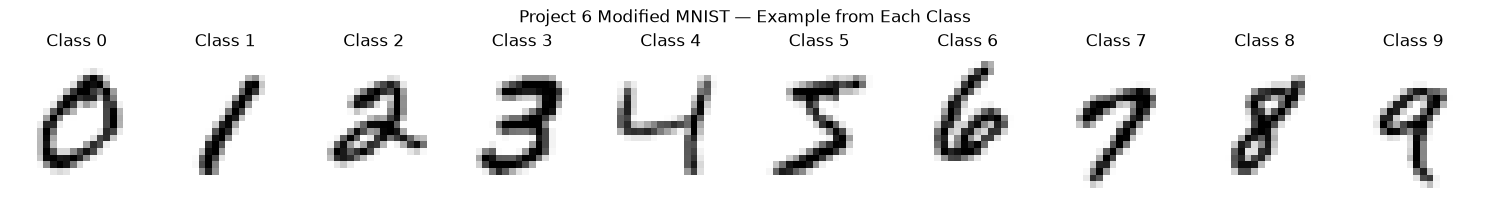

In [18]:
# 1.1.9 — Visualise One Training Example per Class

fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for digit in range(10):
    # Find the first training example belonging to this class
    index = torch.where(train_labels == digit)[0][0]

    image = train_images[index].squeeze()

    axes[digit].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[digit].set_title(f"Class {digit}")
    axes[digit].axis("off")

plt.suptitle("Project 6 Modified MNIST — Example from Each Class")
plt.tight_layout()
plt.show()

## 1.2 Baseline cVAE Architecture

Implement the baseline conditional Variational Autoencoder using the architecture
and training principles from Tutorial 8.3.

The model contains:

- a conditional encoder that estimates latent mean and log-variance;
- the VAE reparameterisation step;
- a conditional decoder that reconstructs the input image;
- reconstruction and KL-divergence loss terms.

The project requires a **7-dimensional latent representation**.

The Tutorial 8.3 architecture is adapted to the supplied Project 6 image size
of `1 × 20 × 20` while retaining the same overall cVAE design.

### 1.2.1 - Conditional Encoder

In [20]:
# 1.2.1 — Conditional Encoder

class cEncoder(nn.Module):
    """
    Conditional VAE encoder adapted from Tutorial 8.3.

    Input:
        x    : image tensor [batch_size, 1, 20, 20]
        cond : one-hot class condition [batch_size, num_classes]

    Output:
        mu     : latent mean [batch_size, z_dim]
        logvar : latent log-variance [batch_size, z_dim]
    """

    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()

        self.z_dim = z_dim
        self.num_classes = num_classes

        self.encoder_backbone = nn.Sequential(

            # 1 × 20 × 20 -> 16 × 10 × 10
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 16 × 10 × 10 -> 32 × 5 × 5
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 32 × 5 × 5 -> 64 × 3 × 3
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 64 × 3 × 3 -> 256 × 1 × 1
            nn.Conv2d(
                64,
                256,
                kernel_size=3,
                stride=1,
                padding=0
            ),
            nn.ReLU(),

            nn.Flatten()
        )

        # Concatenate encoded image features with class condition,
        # then predict both mu and logvar.
        self.encoder_head = nn.Sequential(
            nn.Linear(
                256 + num_classes,
                2 * z_dim
            )
        )

    def forward(self, x, cond):

        x = self.encoder_backbone(x)

        # Add the conditional class information.
        x = torch.cat([x, cond], dim=1)

        x = self.encoder_head(x)

        # Split output into latent mean and log-variance.
        mu, logvar = torch.chunk(x, 2, dim=1)

        return mu, logvar

### 1.2.2 - Conditionalk Decoder

In [21]:
# 1.2.2 — Conditional Decoder

class cDecoder(nn.Module):
    """
    Conditional VAE decoder adapted from Tutorial 8.3.

    Input:
        z    : latent vector [batch_size, z_dim]
        cond : one-hot class condition [batch_size, num_classes]

    Output:
        x_hat : reconstructed/generated image
                [batch_size, 1, 20, 20]
    """

    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()

        self.z_dim = z_dim
        self.num_classes = num_classes

        # Combine latent representation and class condition,
        # then project to the decoder feature representation.
        self.decoder_input = nn.Sequential(
            nn.Linear(
                z_dim + num_classes,
                256
            ),
            nn.ReLU()
        )

        self.decoder_backbone = nn.Sequential(

            # 256 -> 256 × 1 × 1
            nn.Unflatten(1, (256, 1, 1)),

            # 256 × 1 × 1 -> 64 × 3 × 3
            nn.ConvTranspose2d(
                256,
                64,
                kernel_size=3,
                stride=1,
                padding=0
            ),
            nn.ReLU(),

            # 64 × 3 × 3 -> 32 × 5 × 5
            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=0
            ),
            nn.ReLU(),

            # 32 × 5 × 5 -> 16 × 10 × 10
            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),

            # 16 × 10 × 10 -> 1 × 20 × 20
            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),

            # Dataset pixels are in [0, 1].
            nn.Sigmoid()
        )

    def forward(self, z, cond):

        # Condition the latent vector on the requested class.
        z = torch.cat([z, cond], dim=1)

        z = self.decoder_input(z)

        x_hat = self.decoder_backbone(z)

        return x_hat

### 1.2.3 - Conditional Variational Autoencoder

In [22]:
# 1.2.3 — Conditional Variational Autoencoder

class cVAE(nn.Module):
    """
    Conditional Variational Autoencoder.

    Combines the conditional encoder and decoder and implements
    the reparameterisation trick used during training.
    """

    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()

        self.encoder = cEncoder(
            z_dim=z_dim,
            num_classes=num_classes
        )

        self.decoder = cDecoder(
            z_dim=z_dim,
            num_classes=num_classes
        )

        self.z_dim = z_dim
        self.num_classes = num_classes

    def encode(self, x, cond):
        return self.encoder(x, cond)

    def decode(self, z, cond):
        return self.decoder(z, cond)

    def reparameterise(self, mu, logvar):
        """
        Reparameterisation trick:

            sigma = exp(0.5 * logvar)
            epsilon ~ N(0, I)
            z = mu + sigma * epsilon
        """

        sigma = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(sigma)

        z = mu + epsilon * sigma

        return z

    def forward(self, x, cond):

        mu, logvar = self.encode(x, cond)

        z = self.reparameterise(
            mu,
            logvar
        )

        x_hat = self.decode(
            z,
            cond
        )

        return x_hat, mu, logvar

### 1.2.4 - Baseline cVAE Loss

In [23]:
# 1.2.4 — Baseline cVAE Loss

def compute_cvae_loss(
    x,
    x_hat,
    mu,
    logvar,
    beta=0.1
):
    """
    Compute the baseline cVAE objective:

        total loss
        = reconstruction loss
        + beta * KL divergence

    This follows the loss formulation used in Tutorial 8.3.
    """

    # Reconstruction loss.
    recon_loss = 100 * F.mse_loss(
        x_hat,
        x,
        reduction="mean"
    )

    # KL divergence between the learned latent distribution
    # and the standard normal prior N(0, I).
    kl_loss = torch.mean(
        -0.5 * torch.sum(
            1
            + logvar
            - mu.pow(2)
            - logvar.exp(),
            dim=1
        )
    )

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

### 1.2.5 - Baseline Model Configuration

In [24]:
# 1.2.5 — Baseline Model Configuration

NUM_CLASSES = 10
Z_DIM = 7
BETA = 0.1

baseline_model = cVAE(
    z_dim=Z_DIM,
    num_classes=NUM_CLASSES
).to(device)

print(baseline_model)

print("\n--- Model configuration ---")
print(f"Input shape:       1 × 20 × 20")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Latent dimensions: {Z_DIM}")
print(f"Beta:              {BETA}")
print(f"Device:            {device}")

total_params = sum(
    p.numel()
    for p in baseline_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in baseline_model.parameters()
    if p.requires_grad
)

print("\n--- Parameter count ---")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

cVAE(
  (encoder): cEncoder(
    (encoder_backbone): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
    )
    (encoder_head): Sequential(
      (0): Linear(in_features=266, out_features=14, bias=True)
    )
  )
  (decoder): cDecoder(
    (decoder_input): Sequential(
      (0): Linear(in_features=17, out_features=256, bias=True)
      (1): ReLU()
    )
    (decoder_backbone): Sequential(
      (0): Unflatten(dim=1, unflattened_size=(256, 1, 1))
      (1): ConvTranspose2d(256, 64, kernel_size=(3, 3), stride=(1, 1))
      (2): ReLU()
      (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    

### 1.2.6 - Architectuer Shape Check

In [25]:
# 1.2.6 — Architecture Shape Check

baseline_model.eval()

with torch.no_grad():

    # Small synthetic batch.
    shape_test_x = torch.rand(
        4,
        1,
        20,
        20,
        device=device
    )

    shape_test_labels = torch.tensor(
        [0, 1, 2, 3],
        device=device
    )

    shape_test_cond = F.one_hot(
        shape_test_labels,
        num_classes=NUM_CLASSES
    ).float()

    # Encoder
    shape_test_mu, shape_test_logvar = baseline_model.encode(
        shape_test_x,
        shape_test_cond
    )

    # Reparameterisation
    shape_test_z = baseline_model.reparameterise(
        shape_test_mu,
        shape_test_logvar
    )

    # Decoder
    shape_test_x_hat = baseline_model.decode(
        shape_test_z,
        shape_test_cond
    )

print(f"Input:          {tuple(shape_test_x.shape)}")
print(f"Condition:      {tuple(shape_test_cond.shape)}")
print(f"Latent mu:      {tuple(shape_test_mu.shape)}")
print(f"Latent logvar:  {tuple(shape_test_logvar.shape)}")
print(f"Latent sample:  {tuple(shape_test_z.shape)}")
print(f"Reconstruction: {tuple(shape_test_x_hat.shape)}")

Input:          (4, 1, 20, 20)
Condition:      (4, 10)
Latent mu:      (4, 7)
Latent logvar:  (4, 7)
Latent sample:  (4, 7)
Reconstruction: (4, 1, 20, 20)


### 1.2.7 - Full Forward-Pass and Loss Check

In [26]:
# 1.2.7 — Full Forward-Pass and Loss Check

baseline_model.eval()

batch_images, batch_labels = next(
    iter(train_dataloader)
)

batch_images = batch_images.to(device)

batch_conditions = F.one_hot(
    batch_labels,
    num_classes=NUM_CLASSES
).float().to(device)

with torch.no_grad():

    x_hat, mu, logvar = baseline_model(
        batch_images,
        batch_conditions
    )

    total_loss, recon_loss, kl_loss = compute_cvae_loss(
        batch_images,
        x_hat,
        mu,
        logvar,
        beta=BETA
    )

print(f"Input batch:          {tuple(batch_images.shape)}")
print(f"Reconstruction batch: {tuple(x_hat.shape)}")

print("\n--- Initial untrained loss ---")
print(f"Total loss:          {total_loss.item():.4f}")
print(f"Reconstruction loss: {recon_loss.item():.4f}")
print(f"KL loss:             {kl_loss.item():.4f}")

Input batch:          (1000, 1, 20, 20)
Reconstruction batch: (1000, 1, 20, 20)

--- Initial untrained loss ---
Total loss:          18.6202
Reconstruction loss: 18.6190
KL loss:             0.0118


## 1.3 Baseline Training

Train the baseline cVAE on the supplied training dataset using the Project 6
configuration.

Training and test losses are recorded across epochs to assess convergence.
The resulting training configuration will also provide the shared settings used
where possible by the discriminator-loss model in Task 2, ensuring that the
later comparison remains controlled.

### 1.3.1 batch prepare helper

In [27]:
# 1.3.1 — Batch Preparation Helper

def get_batch(batch, device, num_classes=10):
    """
    Move a dataset batch to the selected device and convert
    integer class labels into one-hot conditional vectors.

    Returns:
        x     : image batch
        cond  : one-hot class conditions
    """

    x = batch[0].to(device)

    labels = batch[1].to(device)

    cond = F.one_hot(
        labels,
        num_classes=num_classes
    ).float()

    return x, cond

### 1.3.2 - Baseline Training Function

In [28]:
# 1.3.2 — Baseline Training Function

def train_baseline_cvae(
    model,
    train_dataloader,
    test_dataloader,
    num_epochs,
    device,
    beta=0.1
):
    """
    Train the baseline cVAE and record training/test loss history.

    Training uses stochastic latent samples through the
    reparameterisation step.

    Validation follows Tutorial 8.3 by decoding the latent mean (mu)
    directly, providing deterministic reconstructions.
    """

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.001,
        eps=1e-5,
        fused=False,
        betas=(0.75, 0.99)
    )

    history = {
        "train_total": [],
        "train_recon": [],
        "train_kl": [],
        "test_total": [],
        "test_recon": [],
        "test_kl": []
    }

    for epoch in range(num_epochs):

        # ============================================================
        # Training
        # ============================================================

        model.train()

        train_total = 0.0
        train_recon = 0.0
        train_kl = 0.0

        train_batches = 0

        pbar = tqdm(
            train_dataloader,
            unit="batch",
            desc=f"Epoch {epoch + 1:02d}/{num_epochs} - training",
            colour="GREEN"
        )

        for batch in pbar:

            x, cond = get_batch(
                batch,
                device,
                num_classes=NUM_CLASSES
            )

            optimizer.zero_grad()

            # Full stochastic cVAE forward pass.
            x_hat, mu, logvar = model(
                x,
                cond
            )

            total_loss, recon_loss, kl_loss = compute_cvae_loss(
                x,
                x_hat,
                mu,
                logvar,
                beta=beta
            )

            total_loss.backward()

            optimizer.step()

            # Record scalar values only.
            train_total += total_loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()

            train_batches += 1

            pbar.set_postfix(
                loss=f"{total_loss.item():.4f}"
            )

        train_total /= train_batches
        train_recon /= train_batches
        train_kl /= train_batches

        # ============================================================
        # Validation / Test
        # ============================================================

        model.eval()

        test_total = 0.0
        test_recon = 0.0
        test_kl = 0.0

        test_batches = 0

        with torch.no_grad():

            pbar = tqdm(
                test_dataloader,
                unit="batch",
                desc=f"Epoch {epoch + 1:02d}/{num_epochs} - testing",
                colour="CYAN"
            )

            for batch in pbar:

                x, cond = get_batch(
                    batch,
                    device,
                    num_classes=NUM_CLASSES
                )

                # Tutorial 8.3 validation behaviour:
                # use latent mean rather than stochastic sampling.
                mu, logvar = model.encode(
                    x,
                    cond
                )

                x_hat = model.decode(
                    mu,
                    cond
                )

                total_loss, recon_loss, kl_loss = compute_cvae_loss(
                    x,
                    x_hat,
                    mu,
                    logvar,
                    beta=beta
                )

                test_total += total_loss.item()
                test_recon += recon_loss.item()
                test_kl += kl_loss.item()

                test_batches += 1

        test_total /= test_batches
        test_recon /= test_batches
        test_kl /= test_batches

        # ============================================================
        # Store epoch results
        # ============================================================

        history["train_total"].append(train_total)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)

        history["test_total"].append(test_total)
        history["test_recon"].append(test_recon)
        history["test_kl"].append(test_kl)

        print(
            f"\nEpoch {epoch + 1:02d}/{num_epochs} | "
            f"Train: {train_total:.4f} | "
            f"Test: {test_total:.4f} | "
            f"Recon: {test_recon:.4f} | "
            f"KL: {test_kl:.4f}"
        )

    return history

### 1.3.3 - Train the Baseline Model

In [29]:
# 1.3.3 — Train the Baseline cVAE

BASELINE_EPOCHS = 50

baseline_history = train_baseline_cvae(
    model=baseline_model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    num_epochs=BASELINE_EPOCHS,
    device=device,
    beta=BETA
)

Epoch 01/50 - testing: 100%|██████████| 10/10 [00:00<00:00, 59.73batch/s]



Epoch 01/50 | Train: 9.4802 | Test: 5.9786 | Recon: 5.9188 | KL: 0.5980


Epoch 02/50 - testing: 100%|██████████| 10/10 [00:00<00:00, 57.87batch/s]



Epoch 02/50 | Train: 5.3318 | Test: 4.8833 | Recon: 4.7799 | KL: 1.0338


Epoch 03/50 - testing: 100%|██████████| 10/10 [00:00<00:00, 34.96batch/s]


...


Epoch 48/50 | Train: 2.3397 | Test: 2.0340 | Recon: 1.2396 | KL: 7.9447


Epoch 49/50 - testing: 100%|██████████| 10/10 [00:00<00:00, 60.05batch/s]



Epoch 49/50 | Train: 2.3262 | Test: 2.0126 | Recon: 1.2376 | KL: 7.7498


Epoch 50/50 - testing: 100%|██████████| 10/10 [00:00<00:00, 62.18batch/s]


Epoch 50/50 | Train: 2.3302 | Test: 2.0212 | Recon: 1.2318 | KL: 7.8942


### 1.3.4 - Plot Total Loss History

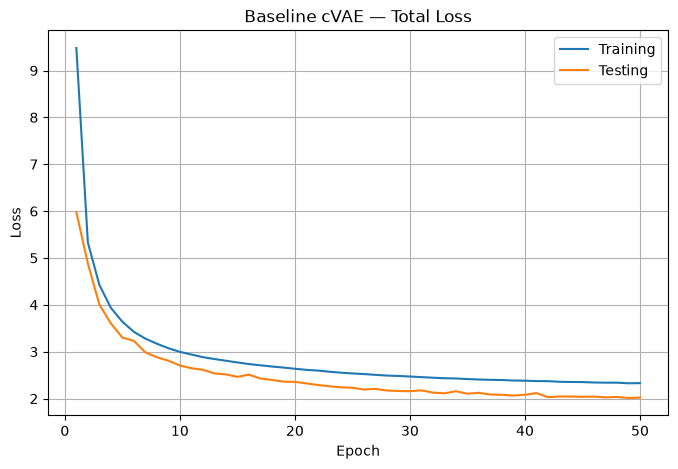

In [31]:
# 1.3.4 — Plot Baseline Total Loss History

epochs = np.arange(
    1,
    len(baseline_history["train_total"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    baseline_history["train_total"],
    label="Training"
)

plt.plot(
    epochs,
    baseline_history["test_total"],
    label="Testing"
)

plt.title("Baseline cVAE — Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

### 1.3.5 - Plot Loss Components

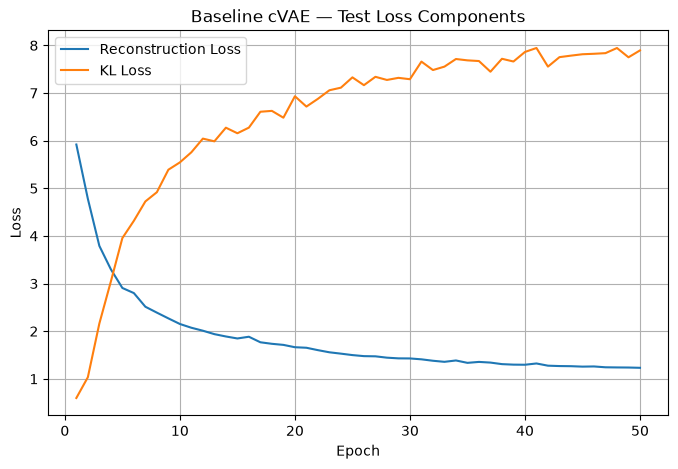

In [32]:
# 1.3.5 — Plot Baseline Loss Components

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    baseline_history["test_recon"],
    label="Reconstruction Loss"
)

plt.plot(
    epochs,
    baseline_history["test_kl"],
    label="KL Loss"
)

plt.title("Baseline cVAE — Test Loss Components")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

### 1.3.6 - Summarise Final Training State

In [33]:
# 1.3.6 — Summarise Baseline Training

final_epoch = len(
    baseline_history["train_total"]
)

print("--- Baseline cVAE Training Summary ---")
print(f"Epochs completed: {final_epoch}")

print("\nFinal training losses:")
print(
    f"  Total:          "
    f"{baseline_history['train_total'][-1]:.4f}"
)
print(
    f"  Reconstruction: "
    f"{baseline_history['train_recon'][-1]:.4f}"
)
print(
    f"  KL:             "
    f"{baseline_history['train_kl'][-1]:.4f}"
)

print("\nFinal test losses:")
print(
    f"  Total:          "
    f"{baseline_history['test_total'][-1]:.4f}"
)
print(
    f"  Reconstruction: "
    f"{baseline_history['test_recon'][-1]:.4f}"
)
print(
    f"  KL:             "
    f"{baseline_history['test_kl'][-1]:.4f}"
)

--- Baseline cVAE Training Summary ---
Epochs completed: 50

Final training losses:
  Total:          2.3302
  Reconstruction: 1.5425
  KL:             7.8763

Final test losses:
  Total:          2.0212
  Reconstruction: 1.2318
  KL:             7.8942


### BASELINE NOTES

Task 1 baseline:
- 50 epochs
- stable convergence
- final train total = 2.3302
- final test total  = 2.0212
- final test recon  = 1.2318
- final test KL     = 7.8942

## 1.4 Baseline Sanity Checks and Artefacts

Perform lightweight checks that the trained baseline model reconstructs and
conditionally generates reasonable digit images.

These outputs are used only to verify successful Task 1 training. The formal
visual and quantitative comparison between the baseline and discriminator-loss
models is reserved for Task 3.

The trained baseline model and its training history are saved for later
evaluation.

### 1.4.1 - Reconstructuion Sanity Check

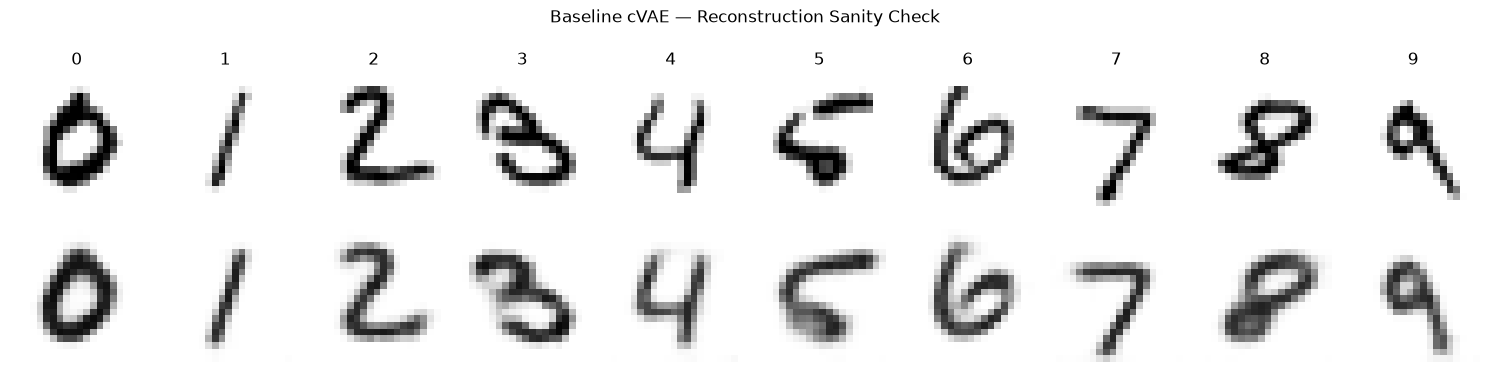

In [36]:
# 1.4.1 — Baseline Reconstruction Sanity Check

baseline_model.eval()

# Select one test example from each digit class.
selected_indices = [
    torch.where(test_labels == digit)[0][0].item()
    for digit in range(NUM_CLASSES)
]

recon_images = test_images[selected_indices].to(device)
recon_labels = test_labels[selected_indices].to(device)

recon_conditions = F.one_hot(
    recon_labels,
    num_classes=NUM_CLASSES
).float()

with torch.no_grad():

    # Deterministic reconstruction using latent mean.
    mu, logvar = baseline_model.encode(
        recon_images,
        recon_conditions
    )

    reconstructed_images = baseline_model.decode(
        mu,
        recon_conditions
    )

# Move images back to CPU for plotting.
originals = recon_images.cpu()
reconstructions = reconstructed_images.cpu()

fig, axes = plt.subplots(
    2,
    NUM_CLASSES,
    figsize=(15, 4)
)

for digit in range(NUM_CLASSES):

    # Original
    axes[0, digit].imshow(
        originals[digit].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, digit].set_title(f"{digit}")
    axes[0, digit].axis("off")

    # Reconstruction
    axes[1, digit].imshow(
        reconstructions[digit].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, digit].axis("off")

axes[0, 0].set_ylabel(
    "Original",
    fontsize=11
)

axes[1, 0].set_ylabel(
    "Reconstructed",
    fontsize=11
)

plt.suptitle(
    "Baseline cVAE — Reconstruction Sanity Check"
)

plt.tight_layout()
plt.show()

### 1.4.2 - Conditional Generation sanity Check

In [37]:
# 1.4.2 — Baseline Conditional Generation Sanity Check

baseline_model.eval()

SANITY_SAMPLES_PER_CLASS = 5

# Fixed seed for reproducible sanity samples.
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

generated_images = []

with torch.no_grad():

    for digit in range(NUM_CLASSES):

        # Sample latent vectors from the standard normal prior.
        z = torch.randn(
            SANITY_SAMPLES_PER_CLASS,
            Z_DIM,
            device=device
        )

        labels = torch.full(
            (SANITY_SAMPLES_PER_CLASS,),
            digit,
            dtype=torch.long,
            device=device
        )

        conditions = F.one_hot(
            labels,
            num_classes=NUM_CLASSES
        ).float()

        samples = baseline_model.decode(
            z,
            conditions
        )

        generated_images.append(
            samples.cpu()
        )

generated_images = torch.stack(
    generated_images
)

print(
    "Generated image tensor:",
    tuple(generated_images.shape)
)

Generated image tensor: (10, 5, 1, 20, 20)


### 1.4.3 — Visualise Conditional Samples

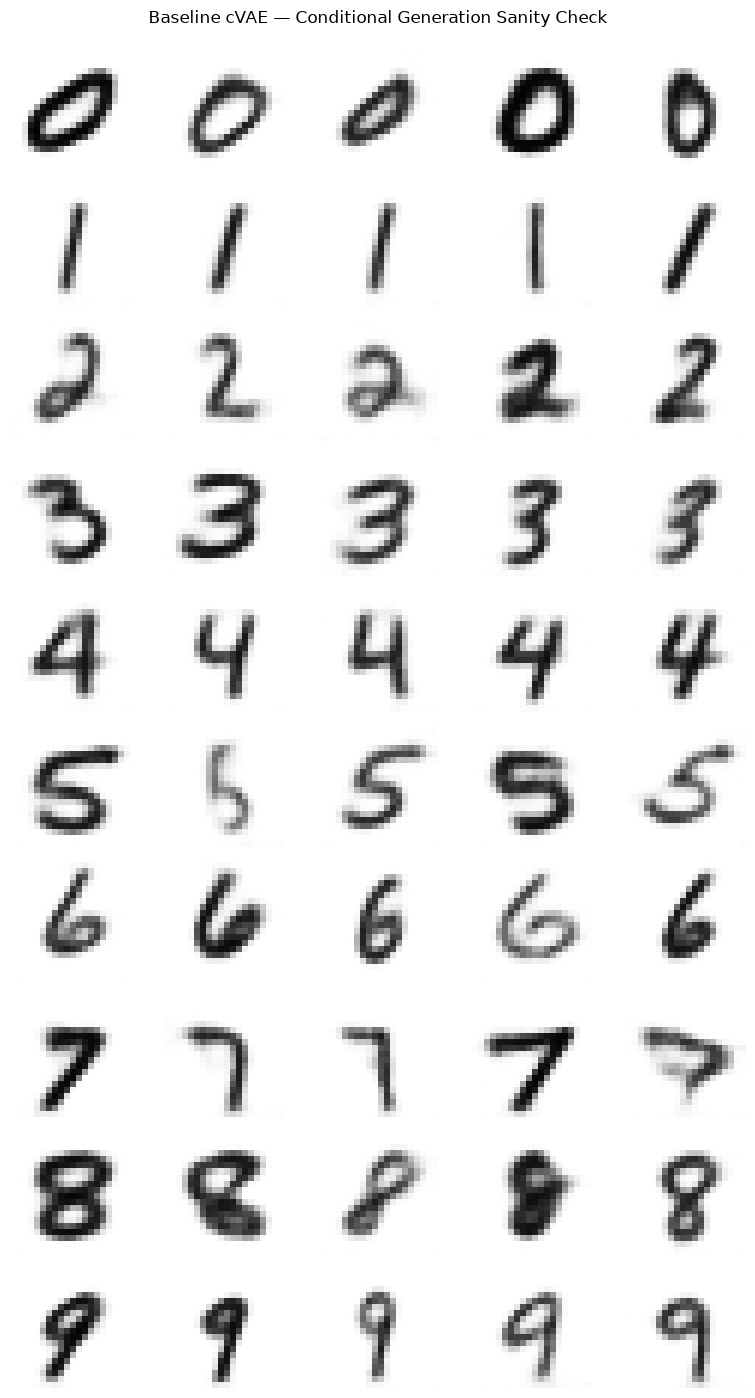

In [38]:
# 1.4.3 — Visualise Baseline Conditional Samples

fig, axes = plt.subplots(
    NUM_CLASSES,
    SANITY_SAMPLES_PER_CLASS,
    figsize=(8, 14)
)

for digit in range(NUM_CLASSES):

    for sample_idx in range(SANITY_SAMPLES_PER_CLASS):

        axes[digit, sample_idx].imshow(
            generated_images[
                digit,
                sample_idx
            ].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[digit, sample_idx].axis("off")

        if sample_idx == 0:
            axes[digit, sample_idx].set_ylabel(
                f"Class {digit}",
                fontsize=10
            )

plt.suptitle(
    "Baseline cVAE — Conditional Generation Sanity Check",
    y=0.995
)

plt.tight_layout()
plt.show()

### 1.4.4 — Save Baseline Checkpoint

In [40]:
# 1.4.4 — Save Baseline Model Checkpoint

BASELINE_MODEL_PATH = Path(
    "./baseline_cvae.pt"
)

baseline_checkpoint = {
    "model_state_dict": baseline_model.state_dict(),

    "config": {
        "input_shape": (1, 20, 20),
        "num_classes": NUM_CLASSES,
        "z_dim": Z_DIM,
        "beta": BETA,
        "epochs": BASELINE_EPOCHS,
        "batch_size_train": BS_TRAIN,
        "batch_size_test": BS_TEST,
        "seed": SEED
    }
}

torch.save(
    baseline_checkpoint,
    BASELINE_MODEL_PATH
)

print(
    f"Baseline checkpoint saved to: "
    f"{BASELINE_MODEL_PATH.resolve()}"
)

Baseline checkpoint saved to: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project6/baseline_cvae.pt


### 1.4.5 — Save Baseline Training History

In [41]:
# 1.4.5 — Save Baseline Training History

BASELINE_HISTORY_PATH = Path(
    "./baseline_history.pt"
)

torch.save(
    baseline_history,
    BASELINE_HISTORY_PATH
)

print(
    f"Baseline training history saved to: "
    f"{BASELINE_HISTORY_PATH.resolve()}"
)

Baseline training history saved to: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project6/baseline_history.pt


### 1.4.6 - Verify Save Baseline Artefcats

In [42]:
# 1.4.6 — Verify Baseline Artefacts

artefacts = [
    BASELINE_MODEL_PATH,
    BASELINE_HISTORY_PATH
]

for path in artefacts:

    if not path.exists():
        raise FileNotFoundError(
            f"Expected artefact was not saved: {path}"
        )

    print(
        f"{path.name:25s} "
        f"{path.stat().st_size / 1024:.2f} KB"
    )

baseline_cvae.pt          1376.00 KB
baseline_history.pt       4.03 KB
